In [1]:
import sys, os
sys.path.insert(0, '/home/aiscuser/verl')
os.environ['CUDA_VISIBLE_DEVICES'] = '4,5,6,7'

In [32]:
from verl.trainer.ppo.ray_trainer import RayPPOTrainer
import ray
import hydra
import torch
from verl.utils.fs import copy_to_local
from pprint import pprint
from omegaconf import OmegaConf
from verl.trainer.main_ppo import *
from verl.utils import hf_tokenizer, hf_processor
from verl.utils.dataset.rl_dataset import RLHFDataset, collate_fn
from verl import DataProto
from codetiming import Timer
import matplotlib.pyplot as plt

In [33]:
ray.init(address='localhost:63540')

2025-04-10 10:16:40,168	INFO worker.py:1660 -- Connecting to existing Ray cluster at address: 100.64.27.254:63540...
2025-04-10 10:16:40,176	INFO worker.py:1843 -- Connected to Ray cluster. View the dashboard at 127.0.0.1:8266 


Python version:,3.9.19
Ray version:,2.44.1
Dashboard:,http://127.0.0.1:8266


In [34]:
config = '/home/aiscuser/verl/verl/trainer/config/dapo_qwen2.5_7b.yaml'
config = OmegaConf.load(config)
OmegaConf.resolve(config)

In [35]:
local_path = copy_to_local(config.actor_rollout_ref.model.path)
tokenizer = hf_tokenizer(local_path)
processor = hf_processor(local_path, use_fast=True)  # used for multimodal LLM, could be none

# define worker classes
if config.actor_rollout_ref.actor.strategy == 'fsdp':
    assert config.actor_rollout_ref.actor.strategy == config.critic.strategy
    from verl.workers.fsdp_workers import ActorRolloutRefWorker, CriticWorker
    from verl.single_controller.ray import RayWorkerGroup
    ray_worker_group_cls = RayWorkerGroup

from verl.trainer.ppo.ray_trainer import ResourcePoolManager, Role

role_worker_mapping = {
    Role.ActorRollout: ray.remote(ActorRolloutRefWorker),
    Role.Critic: ray.remote(CriticWorker),
    Role.RefPolicy: ray.remote(ActorRolloutRefWorker)
}

global_pool_id = 'global_pool'
resource_pool_spec = {
    global_pool_id: [config.trainer.n_gpus_per_node] * config.trainer.nnodes,
}
mapping = {
    Role.ActorRollout: global_pool_id,
    Role.Critic: global_pool_id,
    Role.RefPolicy: global_pool_id,
}
if config.reward_model.enable:
    if config.reward_model.strategy == 'fsdp':
        from verl.workers.fsdp_workers import RewardModelWorker
    elif config.reward_model.strategy == 'megatron':
        from verl.workers.megatron_workers import RewardModelWorker
    else:
        raise NotImplementedError
    role_worker_mapping[Role.RewardModel] = ray.remote(RewardModelWorker)
    mapping[Role.RewardModel] = global_pool_id

reward_manager_name = config.reward_model.get("reward_manager", "naive")
if reward_manager_name == 'naive':
    from verl.workers.reward_manager import NaiveRewardManager
    reward_manager_cls = NaiveRewardManager
elif reward_manager_name == 'prime':
    from verl.workers.reward_manager import PrimeRewardManager
    reward_manager_cls = PrimeRewardManager
elif reward_manager_name == 'dapo':
    from verl.workers.reward_manager import DAPORewardManager
    reward_manager_cls = DAPORewardManager
else:

    raise NotImplementedError

compute_score = get_custom_reward_fn(config)
reward_fn = reward_manager_cls(tokenizer=tokenizer,
                                num_examine=0,
                                compute_score=compute_score,
                                reward_fn_key=config.data.reward_fn_key)

# Note that we always use function-based RM for validation
val_reward_fn = reward_manager_cls(tokenizer=tokenizer,
                                    num_examine=1,
                                    compute_score=compute_score,
                                    reward_fn_key=config.data.reward_fn_key)
resource_pool_manager = ResourcePoolManager(resource_pool_spec=resource_pool_spec, mapping=mapping)

trainer = RayPPOTrainer(config=config,
                        tokenizer=tokenizer,
                        processor=processor,
                        role_worker_mapping=role_worker_mapping,
                        resource_pool_manager=resource_pool_manager,
                        ray_worker_group_cls=ray_worker_group_cls,
                        reward_fn=reward_fn,
                        val_reward_fn=val_reward_fn)
trainer.init_workers()

[validate_config] All configuration checks passed successfully!
dataset len: 1791700
dataset len: 960
Size of train dataloader: 27995
Total training steps: 2799500


(pid=555396) INFO 04-10 10:17:11 __init__.py:190] Automatically detected platform rocm.
(pid=555396) WARNING 04-10 10:17:11 rocm.py:33] `fork` method is not supported by ROCm. VLLM_WORKER_MULTIPROC_METHOD is overridden to `spawn` instead.
(WorkerDict pid=555396) os.environ['CUDA_VISIBLE_DEVICES']: 4
(WorkerDict pid=555396) os.environ['LOCAL_RANK']: 0
(WorkerDict pid=555396) os.environ['CUDA_VISIBLE_DEVICES']: 4
(WorkerDict pid=555396) os.environ['LOCAL_RANK']: 0
(pid=555590) INFO 04-10 10:17:17 __init__.py:190] Automatically detected platform rocm.
(pid=555590) WARNING 04-10 10:17:17 rocm.py:33] `fork` method is not supported by ROCm. VLLM_WORKER_MULTIPROC_METHOD is overridden to `spawn` instead.
(pid=555591) INFO 04-10 10:17:17 __init__.py:190] Automatically detected platform rocm.
(pid=555591) WARNING 04-10 10:17:17 rocm.py:33] `fork` method is not supported by ROCm. VLLM_WORKER_MULTIPROC_METHOD is overridden to `spawn` instead.
(WorkerDict pid=555590) os.environ['CUDA_VISIBLE_DEVICE

(WorkerDict pid=555591) You are attempting to use Flash Attention 2.0 with a model not initialized on GPU. Make sure to move the model to GPU after initializing it on CPU with `model.to('cuda')`.
Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]


(WorkerDict pid=555396) Model config after override: Qwen2Config {
(WorkerDict pid=555396)   "_name_or_path": "Qwen/Qwen2.5-7B",
(WorkerDict pid=555396)   "architectures": [
(WorkerDict pid=555396)     "Qwen2ForCausalLM"
(WorkerDict pid=555396)   ],
(WorkerDict pid=555396)   "attention_dropout": 0.0,
(WorkerDict pid=555396)   "embd_pdrop": 0.0,
(WorkerDict pid=555396)   "eos_token_id": 151643,
(WorkerDict pid=555396)   "hidden_act": "silu",
(WorkerDict pid=555396)   "hidden_size": 3584,
(WorkerDict pid=555396)   "initializer_range": 0.02,
(WorkerDict pid=555396)   "intermediate_size": 18944,
(WorkerDict pid=555396)   "max_position_embeddings": 131072,
(WorkerDict pid=555396)   "max_window_layers": 28,
(WorkerDict pid=555396)   "model_type": "qwen2",
(WorkerDict pid=555396)   "num_attention_heads": 28,
(WorkerDict pid=555396)   "num_hidden_layers": 28,
(WorkerDict pid=555396)   "num_key_value_heads": 4,
(WorkerDict pid=555396)   "pad_token_id": 151643,
(WorkerDict pid=555396)   "resid_p

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00,  4.61it/s]


...

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:00<00:01,  2.62it/s]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:00<00:00,  2.23it/s]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:01<00:00,  2.13it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  2.04it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  2.11it/s]
(WorkerDict pid=555396) 
  0%|          | 0/19 [00:00<?, ?it/s]


(WorkerDict pid=555396) [2025-04-10 10:18:22,660] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
(WorkerDict pid=555396) [2025-04-10 10:18:22,661] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
(WorkerDict pid=555396) [2025-04-10 10:18:22,675] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
(WorkerDict pid=555396) [2025-04-10 10:18:22,681] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)


(WorkerDict pid=555396) /opt/conda/envs/ptca/lib/python3.9/site-packages/deepspeed/runtime/zero/linear.py:49: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
(WorkerDict pid=555396)   def forward(ctx, input, weight, bias=None):
(WorkerDict pid=555396) /opt/conda/envs/ptca/lib/python3.9/site-packages/deepspeed/runtime/zero/linear.py:67: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
(WorkerDict pid=555396)   def backward(ctx, grad_output):
(WorkerDict pid=555396) /opt/conda/envs/ptca/lib/python3.9/site-packages/deepspeed/runtime/zero/linear.py:49: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
(WorkerDict pid=555396)   def forward(ctx, input, weight, bias=None):
(WorkerDict pid=555396) /opt/conda/envs/ptca/lib/python

(WorkerDict pid=555396) kwargs: {'n': 16, 'max_new_tokens': 1024, 'presence_penalty': 0.0, 'frequency_penalty': 0.0, 'repetition_penalty': 1.0, 'temperature': 1.0, 'top_k': -1, 'top_p': 1.0, 'ignore_eos': False}
(WorkerDict pid=555396) After building sglang rollout, memory allocated (GB): 7.093081474304199, memory reserved (GB): 22.55078125
(WorkerDict pid=555396) After building sharding manager, memory allocated (GB): 7.093081474304199, memory reserved (GB): 22.55078125



(WorkerDict pid=555396)   warnings.warn(


In [36]:
# val_metrics = trainer._validate()
# pprint(f'Initial validation metrics: {val_metrics}')

## Profiling batch size

In [37]:
def get_batch(batch_size):  
    data = trainer.train_dataloader.dataset[0]
    batch = [data for _ in range(batch_size)]
    batch = collate_fn(batch)
    batch = DataProto.from_single_dict(batch)
    gen_batch = batch.pop(
    batch_keys=['input_ids', 'attention_mask', 'position_ids'],
    non_tensor_batch_keys=['raw_prompt_ids'],
    )
    sampling_params = {
        'do_sample': True,
        'max_new_tokens': 1024,
        'min_new_tokens': 1023,
        'ignore_eos': True,
        'n': 1
    }
    gen_batch.meta_info['sampling_params'] = sampling_params
    return gen_batch

batch_size = 128
gen_batch = get_batch(batch_size)

In [38]:
timer = Timer('generate_sequences')
with timer:
    trainer.actor_rollout_wg.generate_sequences(gen_batch)

(WorkerDict pid=555396) 0 nRanks 04
(WorkerDict pid=555396) node-0:555396:555925 [0] NCCL INFO Channel 18/0 : 0[600000] -> 1[700000] via P2P/IPC comm 0xf59bab0 nRanks 04
(WorkerDict pid=555396) node-0:555396:555925 [0] NCCL INFO Channel 19/0 : 0[600000] -> 1[700000] via P2P/IPC comm 0xf59bab0 nRanks 04
(WorkerDict pid=555396) node-0:555396:555925 [0] NCCL INFO Channel 02/0 : 0[600000] -> 2[800000] via P2P/IPC comm 0xf59bab0 nRanks 04
(WorkerDict pid=555396) node-0:555396:555925 [0] NCCL INFO Channel 03/0 : 0[600000] -> 2[800000] via P2P/IPC comm 0xf59bab0 nRanks 04
(WorkerDict pid=555396) node-0:555396:555925 [0] NCCL INFO Channel 08/0 : 0[600000] -> 2[800000] via P2P/IPC comm 0xf59bab0 nRanks 04
(WorkerDict pid=555396) node-0:555396:555925 [0] NCCL INFO Channel 09/0 : 0[600000] -> 2[800000] via P2P/IPC comm 0xf59bab0 nRanks 04
(WorkerDict pid=555396) node-0:555396:555925 [0] NCCL INFO Channel 14/0 : 0[600000] -> 2[800000] via P2P/IPC comm 0xf59bab0 nRanks 04
(WorkerDict pid=555396) no

Elapsed time: 33.7726 seconds


(WorkerDict pid=555396) /home/aiscuser/sglang/python/sglang/srt/utils.py:689: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
(WorkerDict pid=555396)   tensor_data = torch.ByteTensor(


In [ ]:
batch_sizes = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
elapsed_times = {}
for batch_size in batch_sizes:
    gen_batch = get_batch(batch_size)
    timer = Timer('generate_sequences')
    with timer:
        trainer.actor_rollout_wg.generate_sequences(gen_batch)
    elapsed_times[batch_size] = timer.last

(WorkerDict pid=555396) self.sampling_params={'n': 1, 'max_new_tokens': 1024, 'presence_penalty': 0.0, 'frequency_penalty': 0.0, 'repetition_penalty': 1.0, 'temperature': 1.0, 'top_k': -1, 'top_p': 1.0, 'ignore_eos': True}
(WorkerDict pid=555396) self.sampling_params={'n': 1, 'max_new_tokens': 1024, 'presence_penalty': 0.0, 'frequency_penalty': 0.0, 'repetition_penalty': 1.0, 'temperature': 1.0, 'top_k': -1, 'top_p': 1.0, 'ignore_eos': True} [repeated 4x across cluster]
(WorkerDict pid=555396) self.sampling_params={'n': 1, 'max_new_tokens': 1024, 'presence_penalty': 0.0, 'frequency_penalty': 0.0, 'repetition_penalty': 1.0, 'temperature': 1.0, 'top_k': -1, 'top_p': 1.0, 'ignore_eos': True} [repeated 4x across cluster]
(WorkerDict pid=555396) self.sampling_params={'n': 1, 'max_new_tokens': 1024, 'presence_penalty': 0.0, 'frequency_penalty': 0.0, 'repetition_penalty': 1.0, 'temperature': 1.0, 'top_k': -1, 'top_p': 1.0, 'ignore_eos': True} [repeated 4x across cluster]
(WorkerDict pid=55539

Elapsed time: 6.9727 seconds
Elapsed time: 7.3516 seconds
Elapsed time: 7.8974 seconds
Elapsed time: 9.1254 seconds
Elapsed time: 13.0259 seconds
Elapsed time: 19.6622 seconds
Elapsed time: 37.8318 seconds
Elapsed time: 73.9707 seconds


### Compiled

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


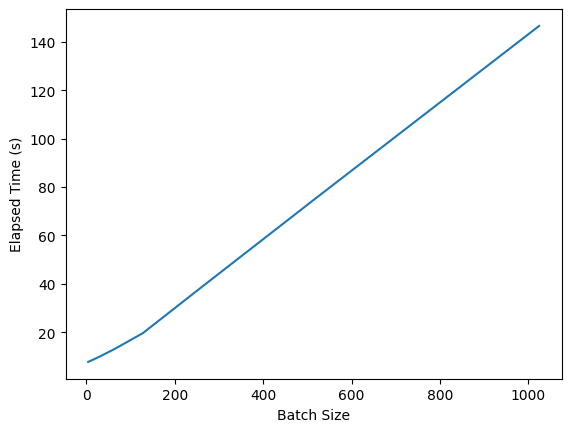

In [30]:
# Plot the elapsed time
plt.plot(batch_sizes, elapsed_times.values())
plt.xlabel('Batch Size')
plt.ylabel('Elapsed Time (s)')
plt.show()

### Non-compiled

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


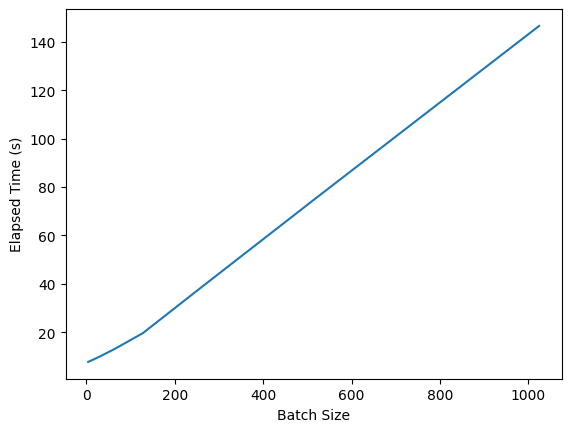

In [ ]:
# Plot the elapsed time
plt.plot(batch_sizes, elapsed_times.values())
plt.xlabel('Batch Size')
plt.ylabel('Elapsed Time (s)')
plt.show()

In [31]:
ray.shutdown()